# 02 — Simulated Annealing

**Curso:** Inteligencia Artificial — Optimización

Este notebook contiene ejemplos guiados y actividades para desarrollar en clase.

## Objetivos

- comprender por qué aceptar temporalmente soluciones peores puede ser útil;
- implementar Simulated Annealing desde cero;
- interpretar el efecto de la temperatura y el calendario de enfriamiento;
- comparar Simulated Annealing con Hill Climbing.

![HillClimbing](https://drive.google.com/uc?export=view&id=13a1dTy2bf9BsgeSZH-cXqJndS1ZKU4DP)



## 1. Un paisaje con varios óptimos

Maximizaremos una función unidimensional multimodal:

$$
f(x)=\sin(3x)+0.35\sin(9x)-0.03(x-2)^2
$$

El algoritmo solo observará valores cercanos al estado actual.

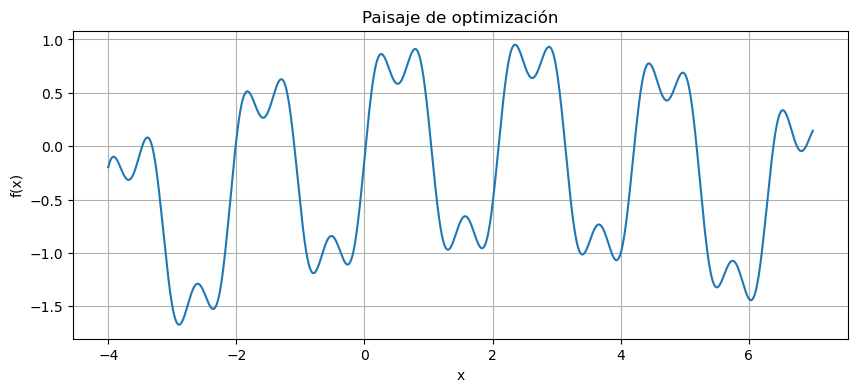

Mejor punto aproximado en la malla: x=2.355, f(x)=0.951


In [1]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt

SEED = 21
random.seed(SEED)
np.random.seed(SEED)


def objective(x):
    return np.sin(3 * x) + 0.35 * np.sin(9 * x) - 0.03 * (x - 2) ** 2

LOWER, UPPER = -4.0, 7.0
xs = np.linspace(LOWER, UPPER, 1500)
ys = objective(xs)

plt.figure(figsize=(10, 4))
plt.plot(xs, ys)
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Paisaje de optimización')
plt.grid(True)
plt.show()

best_grid_x = xs[np.argmax(ys)]
print(f'Mejor punto aproximado en la malla: x={best_grid_x:.3f}, f(x)={objective(best_grid_x):.3f}')

## 2. Hill Climbing estocástico como línea base

Propondremos un vecino mediante una perturbación aleatoria pequeña. Hill Climbing acepta el candidato únicamente cuando mejora la función objetivo.

In [2]:
def random_neighbor(x, step_size, rng, lower=LOWER, upper=UPPER):
    candidate = x + rng.uniform(-step_size, step_size)
    return min(upper, max(lower, candidate))


def stochastic_hill_climbing(x0, iterations=300, step_size=0.35, seed=0):
    rng = random.Random(seed)
    x = x0
    trajectory = [(x, float(objective(x)))]

    for _ in range(iterations):
        candidate = random_neighbor(x, step_size, rng)
        if objective(candidate) > objective(x):
            x = candidate
        trajectory.append((x, float(objective(x))))

    return x, trajectory

x0 = -2.5
hill_x, hill_trajectory = stochastic_hill_climbing(x0, seed=SEED)
print(f'Hill Climbing: x={hill_x:.3f}, f(x)={objective(hill_x):.3f}')

Hill Climbing: x=-2.603, f(x)=-1.288


## 3. Regla de aceptación

Sea

$$
\Delta = f(x')-f(x)
$$

Para maximización:

- si $\Delta>0$, aceptamos el candidato;
- si $\Delta\leq 0$, lo aceptamos con probabilidad

$$
P(\text{aceptar})=\exp\left(\frac{\Delta}{T}\right)
$$

Cuando $T$ es alta, el algoritmo explora. Cuando $T$ disminuye, se vuelve más selectivo.

In [3]:
def simulated_annealing(
    x0,
    iterations=800,
    initial_temperature=1.5,
    cooling_rate=0.992,
    step_size=0.45,
    seed=0
):
    rng = random.Random(seed)
    x = x0
    current_value = float(objective(x))
    best_x, best_value = x, current_value
    temperature = initial_temperature
    records = []

    for iteration in range(iterations):
        candidate = random_neighbor(x, step_size, rng)
        candidate_value = float(objective(candidate))
        delta = candidate_value - current_value

        probability = 1.0 if delta > 0 else math.exp(delta / max(temperature, 1e-12))
        accepted = rng.random() < probability

        if accepted:
            x, current_value = candidate, candidate_value

        if current_value > best_value:
            best_x, best_value = x, current_value

        records.append({
            'iteration': iteration,
            'x': x,
            'value': current_value,
            'best_value': best_value,
            'temperature': temperature,
            'delta': delta,
            'probability': probability,
            'accepted': accepted
        })
        temperature *= cooling_rate

    return best_x, best_value, records

sa_x, sa_value, records = simulated_annealing(x0, seed=SEED)
print(f'Simulated Annealing: x={sa_x:.3f}, f(x)={sa_value:.3f}')

Simulated Annealing: x=0.791, f(x)=0.911


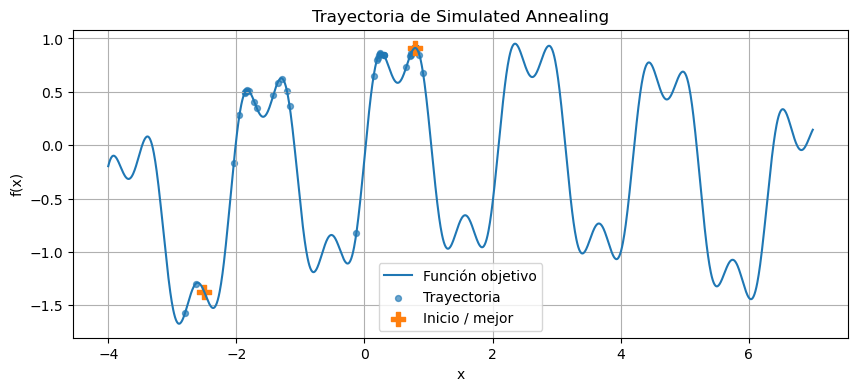

In [4]:
trajectory_x = [r['x'] for r in records]
trajectory_y = [r['value'] for r in records]

plt.figure(figsize=(10, 4))
plt.plot(xs, ys, label='Función objetivo')
plt.scatter(trajectory_x[::12], trajectory_y[::12], s=18, alpha=0.65, label='Trayectoria')
plt.scatter([x0, sa_x], [objective(x0), sa_value], s=100, marker='P', label='Inicio / mejor')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Trayectoria de Simulated Annealing')
plt.legend()
plt.grid(True)
plt.show()

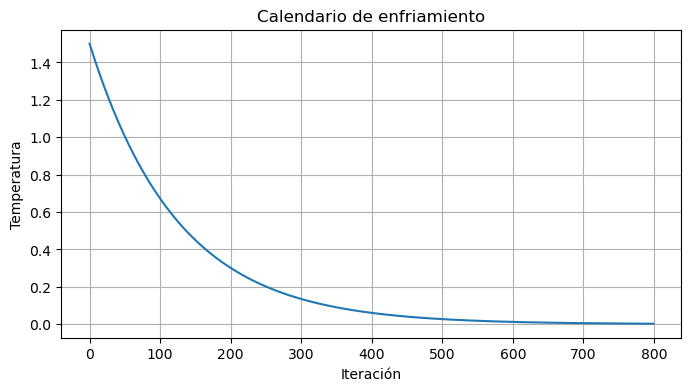

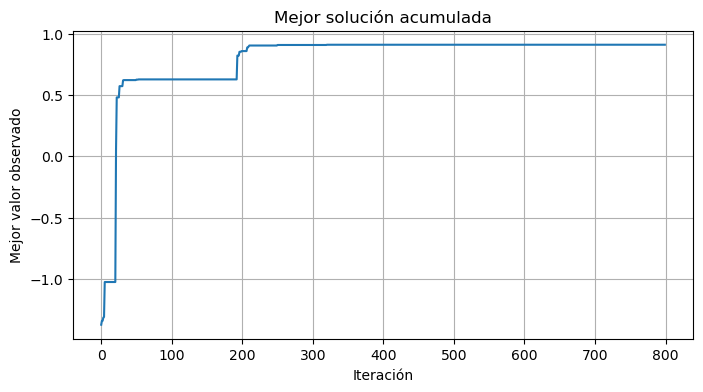

In [5]:
iterations = [r['iteration'] for r in records]
temperatures = [r['temperature'] for r in records]
best_values = [r['best_value'] for r in records]

plt.figure(figsize=(8, 4))
plt.plot(iterations, temperatures)
plt.xlabel('Iteración')
plt.ylabel('Temperatura')
plt.title('Calendario de enfriamiento')
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(iterations, best_values)
plt.xlabel('Iteración')
plt.ylabel('Mejor valor observado')
plt.title('Mejor solución acumulada')
plt.grid(True)
plt.show()

## 4. Comparación estadística

Una sola corrida puede ser engañosa. Compararemos ambos algoritmos usando múltiples semillas y el mismo punto inicial.

Hill Climbing — media: -0.380, mejor: 0.628
Simulated Annealing — media: 0.527, mejor: 0.951


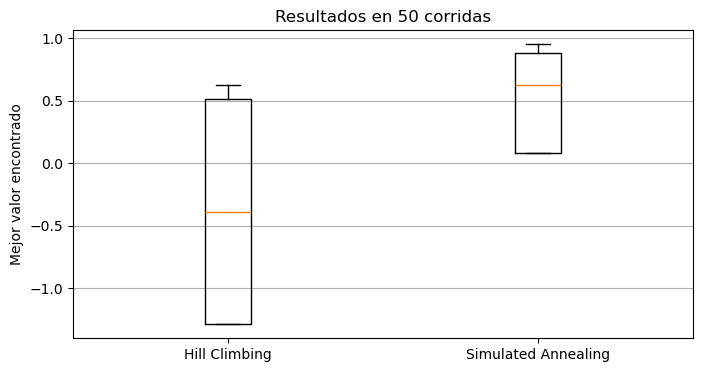

In [6]:
hill_results = []
sa_results = []

for seed in range(50):
    hx, _ = stochastic_hill_climbing(x0, seed=seed)
    sx, sv, _ = simulated_annealing(x0, seed=seed)
    hill_results.append(float(objective(hx)))
    sa_results.append(sv)

print(f'Hill Climbing — media: {np.mean(hill_results):.3f}, mejor: {np.max(hill_results):.3f}')
print(f'Simulated Annealing — media: {np.mean(sa_results):.3f}, mejor: {np.max(sa_results):.3f}')

plt.figure(figsize=(8, 4))
plt.boxplot([hill_results, sa_results], tick_labels=['Hill Climbing', 'Simulated Annealing'])
plt.ylabel('Mejor valor encontrado')
plt.title('Resultados en 50 corridas')
plt.grid(True, axis='y')
plt.show()

## Actividades

### Actividad 1 — Temperatura inicial

Evalúa $T_0\in\{0.01,0.1,0.5,1,3,10\}$. Para cada valor realiza 30 corridas y registra:

- valor medio de la mejor solución;
- desviación estándar;
- porcentaje de corridas que alcanzan un valor cercano al mejor global aproximado.

In [8]:
import numpy as np

# TODO: completa el experimento.
temperatures_to_test = [0.01, 0.1, 0.5, 1, 3, 10]
experiment = []

# Primero corremos todo y guardamos los valores por temperatura
raw_results = {}
for temperature in temperatures_to_test:
    values = []
    for seed in range(30):
        _, value, _ = simulated_annealing(x0, initial_temperature=temperature, seed=seed)
        values.append(value)
    raw_results[temperature] = values

# Estimamos el mejor global aproximado como el máximo entre todas las corridas
best_global_approx = max(v for values in raw_results.values() for v in values)
tolerance = 0.01  # qué tan "cerca" del mejor global se considera aceptable

for temperature in temperatures_to_test:
    values = np.array(raw_results[temperature])
    mean_value = values.mean()
    std_value = values.std()
    close_to_best_pct = (np.abs(values - best_global_approx) <= tolerance).mean() * 100
    experiment.append({
        'temperatura': temperature,
        'valor_promedio': mean_value,
        'SD': std_value,
        'pct_al_optimo': close_to_best_pct
    })

experiment

[{'temperatura': 0.01,
  'valor_promedio': 0.536859789614349,
  'SD': 0.20338321890306546,
  'pct_al_optimo': 0.0},
 {'temperatura': 0.1,
  'valor_promedio': 0.5186573675386745,
  'SD': 0.21831672728543455,
  'pct_al_optimo': 0.0},
 {'temperatura': 0.5,
  'valor_promedio': 0.41896111363220645,
  'SD': 0.27961013024285997,
  'pct_al_optimo': 0.0},
 {'temperatura': 1,
  'valor_promedio': 0.4829598576218552,
  'SD': 0.2980845946987985,
  'pct_al_optimo': 3.3333333333333335},
 {'temperatura': 3,
  'valor_promedio': 0.6393733812947449,
  'SD': 0.3356984387511465,
  'pct_al_optimo': 10.0},
 {'temperatura': 10,
  'valor_promedio': 0.7497419634190947,
  'SD': 0.23314916857848678,
  'pct_al_optimo': 23.333333333333332}]

### Actividad 2 — Enfriamiento

Compara diferentes valores de $\alpha$ en

$$
T_{t+1}=\alpha T_t
$$

Explica por qué un enfriamiento demasiado rápido puede convertir el algoritmo en Hill Climbing.

In [10]:
alphas_to_test = [0.70,0.80, 0.90, 0.95, 0.99, 0.995, 0.999]
cooling_experiment = []

for alpha in alphas_to_test:
    values = []
    for seed in range(30):
        _, value, _ = simulated_annealing(x0, cooling_rate=alpha, seed=seed)
        values.append(value)
    values = np.array(values)
    cooling_experiment.append({
        'alpha': alpha,
        'media': values.mean(),
        'SD': values.std(),
        'min': values.min(),
        'max': values.max()
    })

cooling_experiment

[{'alpha': 0.7,
  'media': 0.4277117002384274,
  'SD': 0.26298310510804807,
  'min': 0.08206886288891646,
  'max': 0.6278250732601802},
 {'alpha': 0.8,
  'media': 0.4095187178968737,
  'SD': 0.26735273082026373,
  'min': 0.08202820281180401,
  'max': 0.6278250273978394},
 {'alpha': 0.9,
  'media': 0.3810055431871396,
  'SD': 0.28271683046422874,
  'min': 0.08205859018204509,
  'max': 0.8639526152571104},
 {'alpha': 0.95,
  'media': 0.382580105507933,
  'SD': 0.2855097983927456,
  'min': 0.0820597361388623,
  'max': 0.9109308817282363},
 {'alpha': 0.99,
  'media': 0.4868852189566006,
  'SD': 0.32821633592955635,
  'min': 0.0820684339371266,
  'max': 0.9109332871263296},
 {'alpha': 0.995,
  'media': 0.5714379401563204,
  'SD': 0.32175589519243203,
  'min': 0.08204150615539096,
  'max': 0.9510906624734508},
 {'alpha': 0.999,
  'media': 0.8511499583554326,
  'SD': 0.18318005665256,
  'min': 0.08208815427838856,
  'max': 0.9510902728835003}]

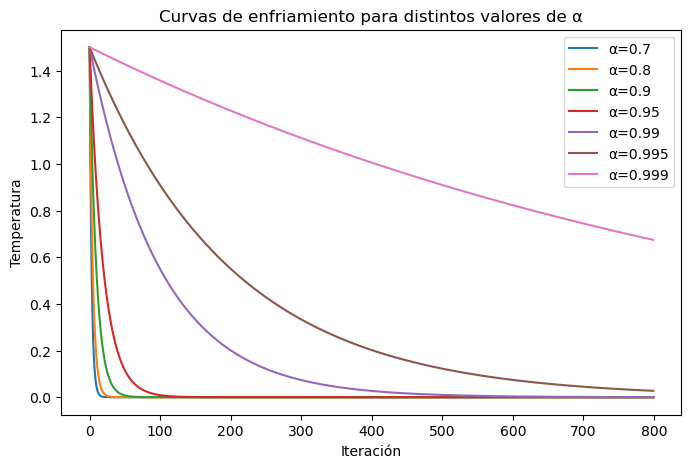

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
for alpha in alphas_to_test:
    temps = [1.5 * (alpha ** t) for t in range(800)]
    plt.plot(temps, label=f'α={alpha}')
plt.xlabel('Iteración')
plt.ylabel('Temperatura')
plt.legend()
plt.title('Curvas de enfriamiento para distintos valores de α')
plt.show()

### Actividad 3 — Problema discreto

Adapta Simulated Annealing al problema de hospitales del notebook anterior. Recuerda que, al minimizar, puedes definir

$$
\Delta = C(	actual)-C(candidato)
$$

para conservar la misma lógica de aceptación usada en este notebook.

In [19]:
def manhattan(a, b):
    return abs(a[0] - b[0]) + abs(a[1] - b[1])


def total_cost(houses, hospitals):
    return sum(min(manhattan(house, hospital) for hospital in hospitals)
               for house in houses)

In [17]:
def plot_state(height, width, houses, hospitals, title=None):
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.set_xlim(-0.5, width - 0.5)
    ax.set_ylim(height - 0.5, -0.5)
    ax.set_xticks(range(width))
    ax.set_yticks(range(height))
    ax.grid(True)

    if houses:
        hr, hc = zip(*houses)
        ax.scatter(hc, hr, marker='s', s=110, label='Casas')
    if hospitals:
        rr, cc = zip(*hospitals)
        ax.scatter(cc, rr, marker='P', s=180, label='Hospitales')

    ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1))
    ax.set_title(title or f'Costo = {total_cost(houses, hospitals)}')
    plt.tight_layout()
    plt.show()

In [21]:
def neighbors_of_state(height, width, houses, hospitals):
    neighbors = []
    moves = [(-1, 0), (1, 0), (0, -1), (0, 1)]

    for hospital in hospitals:
        for dr, dc in moves:
            candidate = (hospital[0] + dr, hospital[1] + dc)
            if not (0 <= candidate[0] < height and 0 <= candidate[1] < width):
                continue
            if candidate in houses or candidate in hospitals:
                continue

            new_state = set(hospitals)
            new_state.remove(hospital)
            new_state.add(candidate)
            neighbors.append(new_state)

    return neighbors

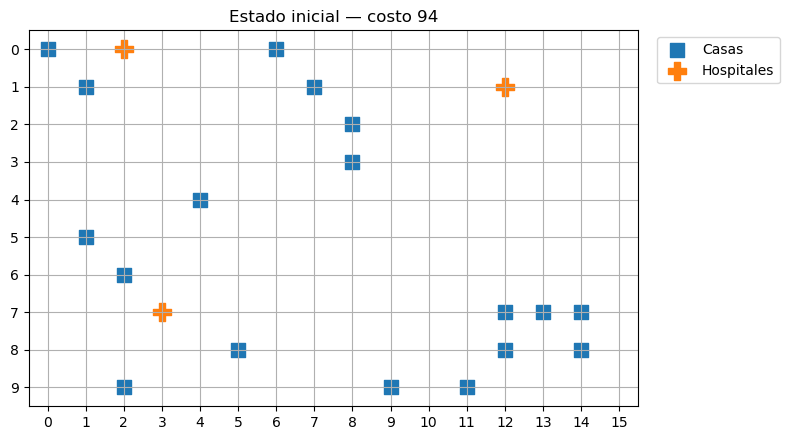

Simulated Annealing (discreto): costo=58


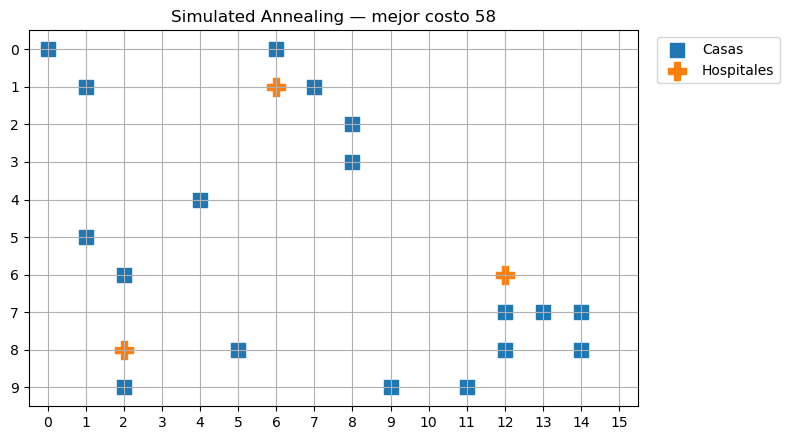

In [22]:
def random_neighbor_state(houses, hospitals, height, width, rng, max_dist=1):
    # Genera todos los vecinos y elige uno al azar
    candidates = neighbors_of_state(height, width, houses, hospitals)
    return candidates[rng.randrange(len(candidates))]

def simulated_annealing_discrete(
    height, width, houses, initial_hospitals,
    iterations=800,
    initial_temperature=1.5,
    cooling_rate=0.992,
    seed=0
):
    rng = random.Random(seed)
    hospitals = set(initial_hospitals)
    current_cost = total_cost(houses, hospitals)
    best_hospitals, best_cost = hospitals, current_cost
    temperature = initial_temperature
    records = []
    for iteration in range(iterations):
        candidate = random_neighbor_state(houses, hospitals, height, width, rng)
        candidate_cost = total_cost(houses, candidate)
        delta = current_cost - candidate_cost  # positivo si el candidato es mejor (menor costo)
        probability = 1.0 if delta > 0 else math.exp(delta / max(temperature, 1e-12))
        accepted = rng.random() < probability
        if accepted:
            hospitals, current_cost = candidate, candidate_cost
        if current_cost < best_cost:
            best_hospitals, best_cost = hospitals, current_cost
        records.append({
            'iteration': iteration,
            'hospitals': hospitals,
            'cost': current_cost,
            'best_cost': best_cost,
            'temperature': temperature,
            'delta': delta,
            'probability': probability,
            'accepted': accepted
        })
        temperature *= cooling_rate
    return best_hospitals, best_cost, records

HEIGHT, WIDTH = 10, 16
NUM_HOUSES = 18
NUM_HOSPITALS = 3
all_cells = [(r, c) for r in range(HEIGHT) for c in range(WIDTH)]
houses = set(random.sample(all_cells, NUM_HOUSES))
available = list(set(all_cells) - houses)
initial_hospitals = set(random.sample(available, NUM_HOSPITALS))
plot_state(HEIGHT, WIDTH, houses, initial_hospitals,
           title=f'Estado inicial — costo {total_cost(houses, initial_hospitals)}')

# NO reescribas houses / initial_hospitals como enteros aquí

sa_hospitals, sa_cost, sa_records = simulated_annealing_discrete(
    HEIGHT, WIDTH, houses, initial_hospitals, seed=SEED
)
print(f'Simulated Annealing (discreto): costo={sa_cost}')
plot_state(HEIGHT, WIDTH, houses, sa_hospitals,
           title=f'Simulated Annealing — mejor costo {sa_cost}')

## Preguntas de cierre

1. ¿Por qué Simulated Annealing conserva la mejor solución observada, además de la solución actual?
Por el criterio de aceptación basado en probabilidad
3. ¿Qué ocurre si la temperatura nunca disminuye?
No hay probabilidad de ir a un estado aleatorio diferente

4. ¿Qué ocurre si la temperatura inicial es prácticamente cero?
La probabilidad de aceptar una mala solucion es casi 1

5. ¿Simulated Annealing garantiza el óptimo global con un número finito de iteraciones?

No lo garantiza pero se acerca de manera mas facil dado el salto aleatorio